In [ ]:
"""
Diffusion models are a type of generative AI that create data like images or audio by starting from random noise and gradually refining it into meaningful output.
They learn this process by adding noise to real data during training and then reversing it step by step. This allows them to generate realistic and high-quality
samples from scratch.

Key Components
Forward Diffusion Process (Noise Addition): A fixed, predefined process that gradually adds Gaussian noise to data over many timesteps, converting structured data into nearly pure noise.

Reverse Diffusion Process (Denoising): A learnable process where a neural network (often a U-Net) predicts and removes noise step by step to reconstruct realistic data from noise.

Score Function (Noise Estimation): Estimates the gradient of the data distribution (or directly predicts noise), guiding each denoising step toward more realistic samples.

Time-Step Conditioning: The model is conditioned on the current timestep, allowing it to understand how much noise is present and how to remove it effectively at each stage.

Sampling Strategy: New data is generated by starting from random noise and iteratively applying the learned reverse steps, often using techniques to improve speed and quality.
"""

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Beta Schedule and Noise Schedule

def linear_beta_schedule(timesteps):
    beta_start = 0.0001
    beta_end = 0.02
    return torch.linspace(beta_start, beta_end, timesteps)

T = 200
betas = linear_beta_schedule(T)

alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, axis=0)

In [3]:
# Forward Diffusion Process

def forward_diffusion_sample(x_0, t, noise=None):
    """
    Add noise to the image x_0 at timestep t
    """
    if noise is None:
        noise = torch.randn_like(x_0)
    sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod[t])[:, None, None, None]
    sqrt_one_minus_alphas_cumprod = torch.sqrt(1 - alphas_cumprod[t])[:, None, None, None]
    return sqrt_alphas_cumprod * x_0 + sqrt_one_minus_alphas_cumprod * noise, noise

In [4]:
#  Neural Network (U Net or simple CNN)

class SimpleModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 1, 3, padding=1),
        )

    def forward(self, x, t):
        return self.net(x)

In [6]:
#  Load Data and Train the Model

def get_data():
    transform = transforms.Compose([
        transforms.ToTensor(), 
        lambda x: x * 2 - 1 
    ])
    # if steel have not downloaded dataset change download flag to True
    dataset = MNIST(root="./data", train=True, download=False, transform=transform)
    dataloader = DataLoader(dataset, batch_size=128, shuffle=True)
    return dataloader

def train(model, dataloader, optimizer, epochs=5):
    for epoch in range(epochs):
        for step, (x, _) in enumerate(dataloader):
            x = x.to(device)
            t = torch.randint(0, T, (x.shape[0],), device=device).long()
            x_noisy, noise = forward_diffusion_sample(x, t)
            noise_pred = model(x_noisy, t)
            loss = F.mse_loss(noise_pred, noise)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        print(f"Epoch {epoch}: Loss {loss.item():.4f}")

In [7]:
#  Sampling (Generating New Images)

@torch.no_grad()
def sample(model, image_size, num_samples):
    model.eval()
    x = torch.randn((num_samples, 1, image_size, image_size), device=device)
    for t in reversed(range(T)):
        t_tensor = torch.full((num_samples,), t, device=device, dtype=torch.long)
        pred_noise = model(x, t_tensor)
        alpha = alphas[t]
        alpha_bar = alphas_cumprod[t]
        beta = betas[t]
        if t > 0:
            noise = torch.randn_like(x)
        else:
            noise = 0
        x = (1 / torch.sqrt(alpha)) * (
            x - (beta / torch.sqrt(1 - alpha_bar)) * pred_noise
        ) + torch.sqrt(beta) * noise
    return x

Epoch 0: Loss 0.1319
Epoch 1: Loss 0.1338
Epoch 2: Loss 0.1082
Epoch 3: Loss 0.0998
Epoch 4: Loss 0.1053


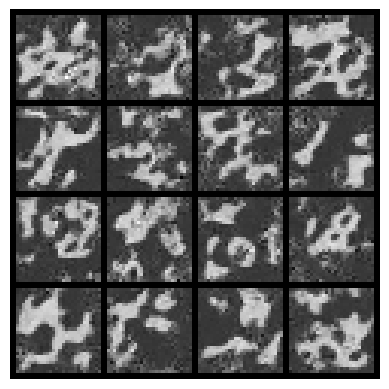

In [8]:
# Running the Model

device = "cuda" if torch.cuda.is_available() else "cpu"
model = SimpleModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
dataloader = get_data()

train(model, dataloader, optimizer)

samples = sample(model, 28, 16)
grid = torchvision.utils.make_grid(samples.cpu(), nrow=4, normalize=True)
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.show()